# Exploratory Data Analysis

This notebook provides an exploratory analysis of the Financial PhraseBank dataset with the goal of developing an initial understanding of its structure, content, and linguistic characteristics. Before applying any machine‑learning methods, it is essential to examine how sentiment is expressed in the data, how the classes differ, and where overlaps or ambiguities occur. The analysis focuses on vocabulary patterns, n‑gram distributions, and TF‑IDF scores to identify tendencies that may inform later feature engineering and modeling decisions.

In [24]:
import sys
from pathlib import Path

project_root = Path().resolve()
while not (project_root / "src").exists():
    project_root = project_root.parent

sys.path.append(str(project_root))

# Import Libraries

In [25]:
import pandas as pd
from src.utils.utils import load_config
from src.data.data import load_txt
from src.features.features import top_ngrams_for_label, clean_text_for_tfidf
import matplotlib.pyplot as plt
import seaborn as sns
import string
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
stop_words = stopwords.words('english')
nltk.download('wordnet')

pd.set_option('display.max_colwidth', None)

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/melanie/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/melanie/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# Dataset Description

In [26]:
config = load_config("configs/config.yaml")

df = load_txt(config['data']['raw_path'], names=['text', 'label'])

In [27]:
summary = {
    "Number of samples": df.shape[0],
    "Number of features": df.shape[1],
    "Missing values per column": df.isna().sum().to_dict(),
    "Duplicate rows": df.duplicated().sum(),
    "Dataset sentiments": sorted(df['label'].unique())
}

for key, value in summary.items():
    print(f"{key}: {value}\n")

print("Types of data:")
print(df.info())


Number of samples: 2264

Number of features: 2

Missing values per column: {'text': 0, 'label': 0}

Duplicate rows: 5

Dataset sentiments: ['negative', 'neutral', 'positive']

Types of data:
<class 'pandas.DataFrame'>
RangeIndex: 2264 entries, 0 to 2263
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    2264 non-null   str  
 1   label   2264 non-null   str  
dtypes: str(2)
memory usage: 35.5 KB
None


The dataset used in this project is the Financial PhraseBank dataset (Financial PhraseBank), which contains financial text phrases labeled with sentiment classes.

It consists of 2,264 samples and 2 columns: text and label. Each entry represents a financial sentence annotated with one of three sentiment classes: negative, neutral, or positive, making this a multi-class text classification problem.
Both columns are stored as string type, which is expected for raw text and categorical labels.Feature extraction techniques such as TF-IDF or other vectorization methods are required when using traditional machine learning models; however, transformer-based models process raw text directly and therefore do not rely on TF-IDF representations. Since most machine learning models require numerical target values, the sentiment labels will be encoded into numeric classes at a later stage of the workflow.

The dataset is complete, with no missing values in either column, indicating that no imputation or data cleaning is required for null handling. Additionally, only 5 duplicate rows were identified.

In [28]:
df[df.duplicated(subset=["text"], keep=False)]

,text,label
518,The issuer is solely responsible for the content of this announcement .,neutral
519,The issuer is solely responsible for the content of this announcement .,neutral
625,"The report profiles 614 companies including many key and niche players worldwide such as Black & Decker Corporation , Fiskars Corporation , Fiskars Brands , Inc. , Husqvarna Outdoor Products Inc. , K+S Group , Ryobi Technologies , Inc. , The Scotts Miracle-Gro Company , and Van Group , Inc. .",neutral
626,"The report profiles 614 companies including many key and niche players worldwide such as Black & Decker Corporation , Fiskars Corporation , Fiskars Brands , Inc. , Husqvarna Outdoor Products Inc. , K+S Group , Ryobi Technologies , Inc. , The Scotts Miracle-Gro Company , and Van Group , Inc. .",neutral
928,Ahlstrom 's share is quoted on the NASDAQ OMX Helsinki .,neutral
929,Ahlstrom 's share is quoted on the NASDAQ OMX Helsinki .,neutral
1026,"SSH Communications Security Corporation is headquartered in Helsinki , Finland .",neutral
1027,"SSH Communications Security Corporation is headquartered in Helsinki , Finland .",neutral
1408,"The company serves customers in various industries , including process and resources , industrial machinery , architecture , building , construction , electrical , transportation , electronics , chemical , petrochemical , energy , and information technology , as well as catering and households .",neutral
1409,"The company serves customers in various industries , including process and resources , industrial machinery , architecture , building , construction , electrical , transportation , electronics , chemical , petrochemical , energy , and information technology , as well as catering and households .",neutral


In [29]:
pd.DataFrame(df[df.duplicated()].groupby("text")["label"].nunique())

,label
text,
Ahlstrom 's share is quoted on the NASDAQ OMX Helsinki .,1
"SSH Communications Security Corporation is headquartered in Helsinki , Finland .",1
"The company serves customers in various industries , including process and resources , industrial machinery , architecture , building , construction , electrical , transportation , electronics , chemical , petrochemical , energy , and information technology , as well as catering and households .",1
The issuer is solely responsible for the content of this announcement .,1
"The report profiles 614 companies including many key and niche players worldwide such as Black & Decker Corporation , Fiskars Corporation , Fiskars Brands , Inc. , Husqvarna Outdoor Products Inc. , K+S Group , Ryobi Technologies , Inc. , The Scotts Miracle-Gro Company , and Van Group , Inc. .",1


Duplicate texts were found in the dataset. Upon inspection, duplicate entries consistently share the same sentiment label. This suggests that duplicates likely originate from repeated news articles rather than labeling errors.

However, duplicates may still introduce bias during model evaluation if not properly handled before train-test splitting.

# 

# Sentiment Distribution Analysis

This chapter examines the distribution of sentiment labels within the Financial PhraseBank dataset. The primary objective is to document how frequently each sentiment class appears in the data and to assess whether the dataset exhibits any notable class imbalance. This is relevant for later modeling steps, as imbalanced label distributions can influence classifier performance and may require additional preprocessing or resampling strategies.

The distribution is visualized using a count plot, providing a clear overview of the relative proportions of the three sentiment categories. To complement the quantitative view, the chapter also presents ten example sentences for each sentiment class, offering a qualitative impression of the linguistic characteristics associated with each label. 

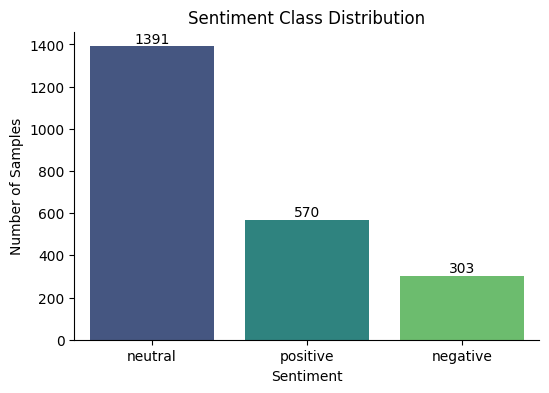

In [30]:
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x='label', palette='viridis', hue='label', legend=False)
ax.set_title("Sentiment Class Distribution")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Number of Samples")

for container in ax.containers:
    ax.bar_label(container)

sns.despine()
plt.show()

The dataset is clearly imbalanced across sentiment classes.

The neutral class dominates the dataset with 1,391 samples, which is significantly higher than both other classes. The positive class contains 570 samples, while the negative class is the smallest group with only 303 samples.

This imbalance suggests that the dataset is skewed towards neutral financial statements, which is typical for financial news data where many sentences are descriptive rather than explicitly positive or negative.

From a modeling perspective, this class imbalance is important because it may bias a classifier toward predicting the neutral class more frequently. Therefore, techniques such as class weighting, resampling, or using evaluation metrics like F1-score instead of accuracy should be considered during model development.

In [31]:
for sentiment in df['label'].unique():
    print(f"\n--- {sentiment.upper()} EXAMPLES ---\n")
    examples = df[df['label'] == sentiment]['text'].head(10)
    for i, text in enumerate(examples, 1):
        print(f"{i}. {text}")


--- NEUTRAL EXAMPLES ---

1. According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .
2. At the request of Finnish media company Alma Media 's newspapers , research manager Jari Kaivo-oja at the Finland Futures Research Centre at the Turku School of Economics has drawn up a future scenario for Finland 's national economy by using a model developed by the University of Denver .
3. STOCK EXCHANGE ANNOUNCEMENT 20 July 2006 1 ( 1 ) BASWARE SHARE SUBSCRIPTIONS WITH WARRANTS AND INCREASE IN SHARE CAPITAL A total of 119 850 shares have been subscribed with BasWare Warrant Program .
4. A maximum of 666,104 new shares can further be subscribed for by exercising B options under the 2004 stock option plan .
5. Tiimari operates 194 stores in six countries -- including its core Finnish market -- and generated a turnover of 76.5 mln eur in 2005 .
6. Finnish Talvivaara Mining Co HEL : TLV1V said Thursday it had picked BofA Merril

The neutral examples predominantly consist of factual, descriptive statements that report events, corporate structures, administrative actions, or technical information without expressing any evaluative judgment. These sentences typically describe organizational decisions, stock exchange notifications, project descriptions, or shareholder information. They lack sentiment‑bearing verbs or adjectives and do not reference financial gains or losses. Their tone is informational, which aligns with the neutral label.

In contrast, the positive examples consistently describe improvements in financial performance, such as increases in net sales, operating profit, or market valuation. Many sentences highlight year‑over‑year growth, transitions from loss to profit, or favorable market reactions. The language frequently includes upward‑oriented terms such as “increased,” “rose,” “doubled,” or “beat expectations,” all of which signal positive business developments.

The negative examples, on the other hand, focus on deteriorating financial conditions. They describe declining sales, reduced earnings, slowed growth, or transitions from profit to loss. The vocabulary includes downward‑oriented expressions such as “struggling,” “fell,” “slipped to a loss,” “decreased,” and “hit by expenditures.” These terms convey financial setbacks or operational difficulties. The negative sentiment is therefore not based on emotional language but on the reporting of adverse business outcomes.

Overall, the examples demonstrate that the sentiment labels in the dataset are primarily driven by financial performance indicators rather than subjective tone. Positive sentences describe improvements or gains, negative sentences report declines or losses, and neutral sentences present factual information without evaluative implications. This pattern reflects the domain‑specific nature of financial sentiment analysis, where sentiment is closely tied to measurable business outcomes rather than emotional expression.

# Text Length Analysis

This chapter examines the role of text length within the dataset used for financial sentiment analysis. The analysis focuses on two basic quantitative measures: character count and word count. These metrics are evaluated both globally and in relation to the assigned sentiment labels.

The goal is not to infer causal relationships, but to document observable patterns in how financial phrases vary in length and whether these variations align with sentiment categories. By establishing these descriptive statistics, the chapter provides a structural overview of the dataset and supports later steps in the sentiment analysis workflow.

In [32]:
df['char_count'] = df['text'].str.len()
df['word_count'] = df["text"].str.replace(f"[{string.punctuation}]", "", regex=True).str.split().str.len()

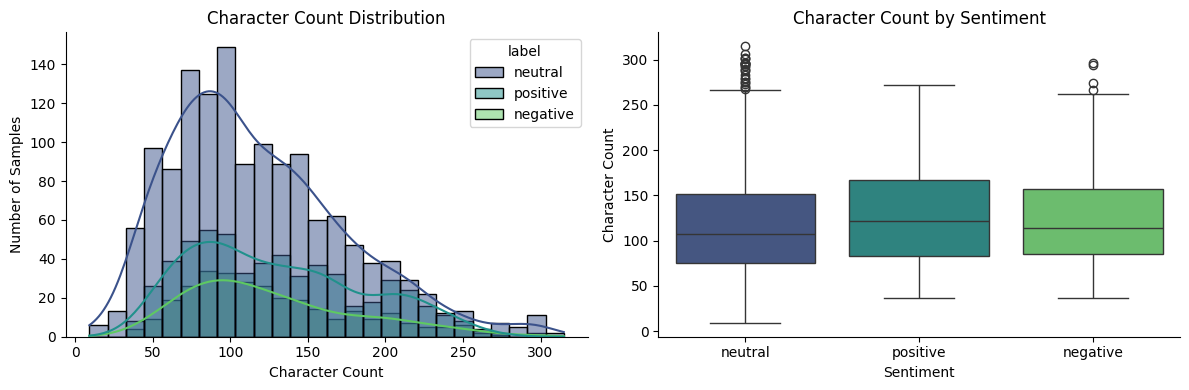

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    data=df,
    x='char_count',
    kde=True,
    hue='label',
    ax=axes[0],
    palette='viridis'
)
axes[0].set_title("Character Count Distribution")
axes[0].set_xlabel("Character Count")
axes[0].set_ylabel("Number of Samples")

sns.boxplot(
    data=df,
    x='label',
    y='char_count',
    ax=axes[1],
    palette= 'viridis',
    hue='label'
)
axes[1].set_title("Character Count by Sentiment")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Character Count")

sns.despine()
plt.tight_layout()
plt.show()

The left plot shows the overall distribution of character counts across all sentiment classes, while the right plot compares character lengths between neutral, positive, and negative sentiments.

Overall, the character count distribution is right-skewed, meaning most financial phrases are relatively short, with a concentration around lower character counts and a long tail of longer texts.

When comparing sentiment classes, the boxplot indicates that positive and negative texts tend to be slightly longer on average than neutral texts, although the difference is not very pronounced. Neutral statements show a tighter distribution and generally shorter length, which is expected since they often describe factual information without strong evaluative language.

Some outliers are present in all classes, indicating occasional longer financial statements or more detailed descriptions.

Overall, character length alone does not strongly separate sentiment classes, but it provides useful insight into the general structure of the dataset and confirms that all classes follow a similar textual length pattern with only minor differences.

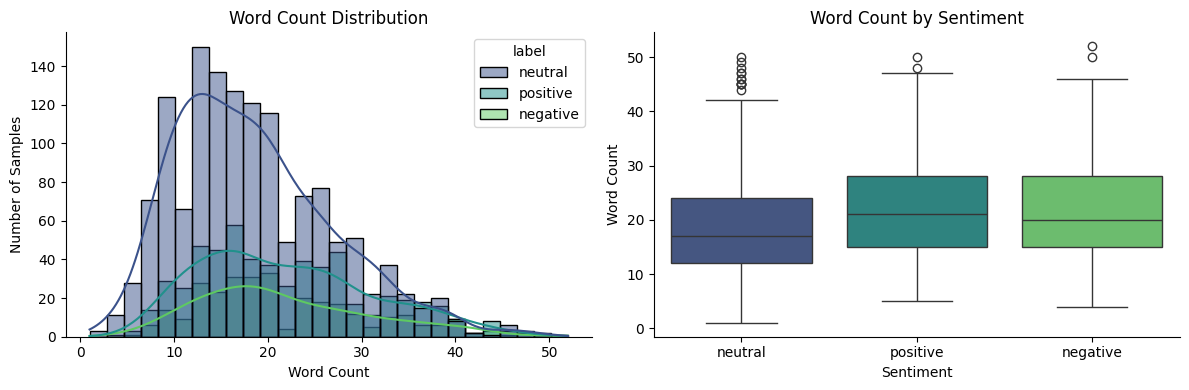

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    data=df,
    x='word_count',
    kde=True,
    hue='label',
    ax=axes[0],
    palette='viridis'
)
axes[0].set_title("Word Count Distribution")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Number of Samples")

sns.boxplot(
    data=df,
    x='label',
    y='word_count',
    ax=axes[1],
    palette= 'viridis',
    hue='label'
)
axes[1].set_title("Word Count by Sentiment")
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Word Count")

sns.despine()
plt.tight_layout()
plt.show()

The left plot shows the overall distribution of word counts across all sentiment classes, while the right plot compares word lengths between neutral, positive, and negative texts.

Overall, the word count distribution is right‑skewed, with most texts being relatively short and clustering around lower word counts, while a smaller number of much longer texts form a long tail. Neutral texts dominate the dataset and create a clear peak in the lower word‑count range.

When comparing sentiment classes, the boxplot indicates that positive and negative texts tend to be slightly longer on average than neutral ones, though the difference is modest. Neutral statements show a tighter, more compact distribution and generally shorter length, which aligns with the expectation that neutral content often conveys factual or descriptive information without additional emotional elaboration.

All sentiment classes contain outliers, reflecting occasional longer statements or more detailed explanations. Overall, word count alone does not strongly differentiate sentiment categories, but it provides useful insight into the dataset’s structure and confirms that all classes follow a broadly similar length pattern with only minor variations.

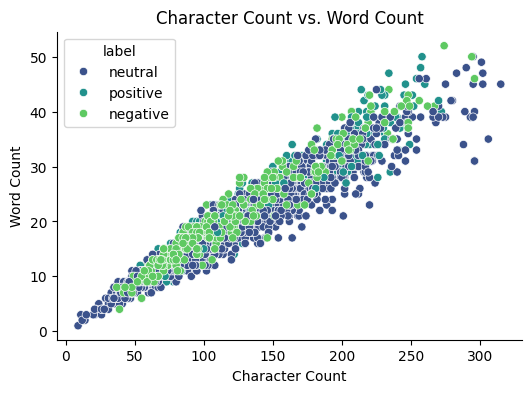

In [35]:
plt.figure(figsize=(6,4))

ax = sns.scatterplot(data=df, x='char_count', y='word_count', hue='label', palette='viridis')

ax.set_title('Character Count vs. Word Count')

ax.set_xlabel('Character Count')

sns.despine()
ax.set_ylabel('Word Count')
plt.show()

# Unigram, Bigram, and Trigram Analysis by Sentiment

This chapter examines the distribution of unigrams, bigrams, and trigrams across the sentiment categories. For each sentiment label, the most frequent n‑grams are derived by cleaning and tokenizing the text, applying lemmatization, and optionally removing stopwords. Based on the processed tokens, relative frequency counts are computed, and the top‑N n‑grams for each configuration are selected.

The resulting n‑gram distributions are visualized using bar plots, enabling a direct comparison of the most common token sequences across sentiments and preprocessing settings. This descriptive analysis provides an overview of recurring lexical patterns in the dataset and supports subsequent steps such as feature selection, vocabulary refinement, and model interpretation.

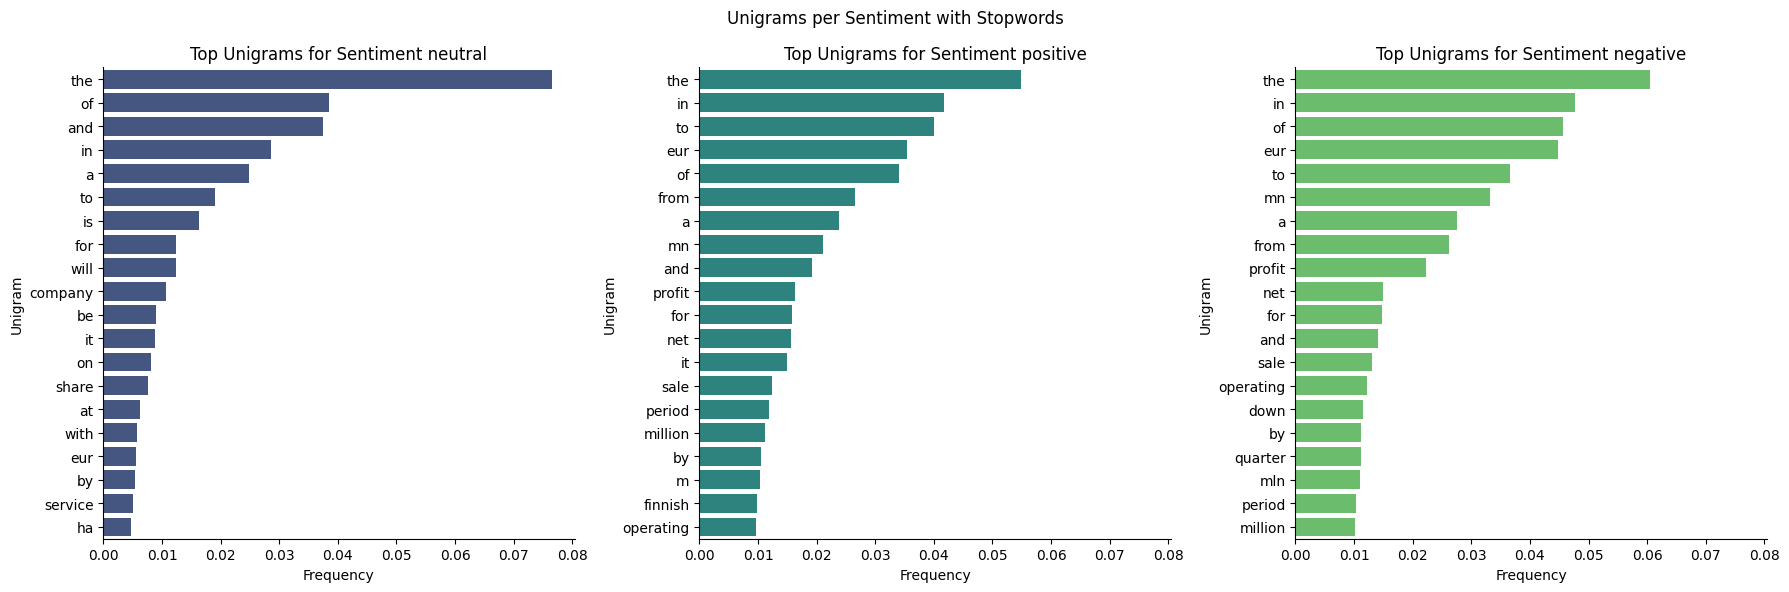

In [36]:
palette = sns.color_palette("viridis", 3)
sentiment_colors = {
    "neutral": palette[0],
    "positive": palette[1],
    "negative": palette[2]
}

labels = df["label"].unique()
num_labels = len(labels)
lemmatizer= WordNetLemmatizer()

fig, axes = plt.subplots(1, num_labels, figsize=(6*num_labels, 6), sharex=True)
fig.suptitle("Unigrams per Sentiment with Stopwords")

for ax, label in zip(axes, labels):
    top_words = top_ngrams_for_label(df, label, [], 1, 20, lemmatizer)
    sns.barplot(x=top_words.values, y=top_words.index, ax=ax, color=sentiment_colors[label])
    ax.set_title(f"Top Unigrams for Sentiment {label}")
    ax.set_xlabel("Frequency")
    ax.set_ylabel("Unigram")

sns.despine()
plt.tight_layout()
plt.show()

When stopwords are retained, the most frequent unigrams across all sentiment classes are dominated by common function words such as the, of, and, in, and to. This is expected, as these tokens occur frequently in all forms of English text and do not carry sentiment on their own. Their presence at the top of the frequency lists reflects the syntactic structure of financial reporting rather than sentiment‑specific patterns. However, beyond these stopwords, the distributions reveal meaningful differences between the sentiment categories.

In the neutral class, the first sentiment‑bearing words that appear are company, share, service, and eur. These terms indicate that neutral sentences often describe corporate structures, administrative actions, or factual financial information without evaluative content. Words like 'will' and 'be' also appear relatively frequently, reflecting the prevalence of forward‑looking statements or procedural descriptions (e.g., announcements, plans, or technical explanations). Overall, the vocabulary is dominated by informational and descriptive terminology.

The positive class shows a shift toward financially favorable terminology. Words such as profit, net, sale, period, million, and operating appear prominently. These tokens are characteristic of sentences reporting financial improvements, growth, or strong performance. The presence of eur, mn, and m reflects the frequent mention of monetary values in positive financial news. Compared to the neutral class, the positive distribution includes more performance‑related nouns, indicating that positive sentiment is closely tied to increases in revenue, profit, or sales.

The negative class shares some vocabulary with the positive class, such as profit, net, sale, operating, and period, but the context in which these words appear differs. Crucially, the negative distribution includes sentiment‑bearing terms such as down, which directly signals decline. Additionally, the prominence of quarter, mln, and million reflects the reporting of financial results, often in the context of losses or deteriorating performance. The overlap in financial terminology between positive and negative classes highlights that sentiment is not determined by the presence of specific financial terms alone, but by the directionality expressed in the surrounding context.

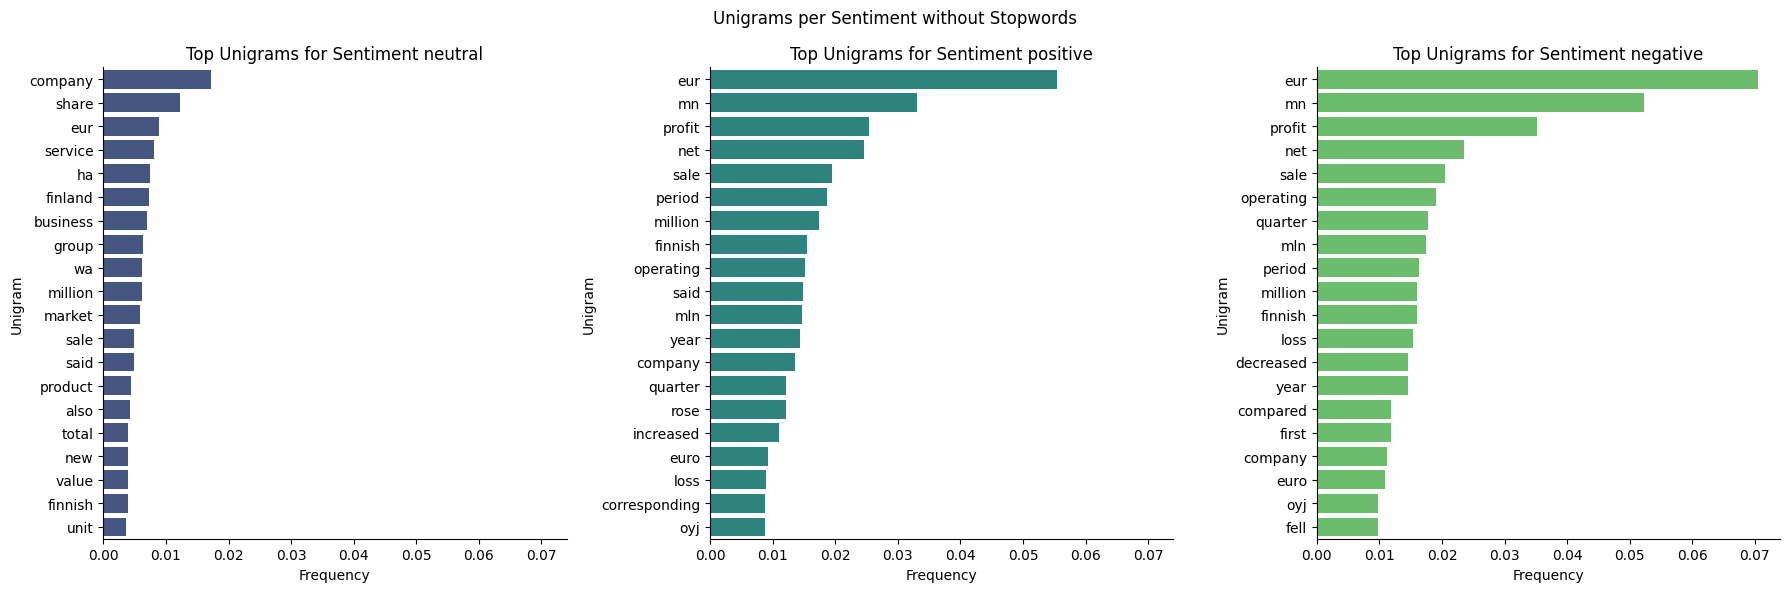

In [37]:
fig, axes = plt.subplots(1, num_labels, figsize=(6*num_labels, 6), sharex=True)
fig.suptitle("Unigrams per Sentiment without Stopwords")

for ax, label in zip(axes, labels):
    top_words = top_ngrams_for_label(df, label, stop_words, 1, 20, lemmatizer)
    sns.barplot(x=top_words.values, y=top_words.index, ax=ax, color=sentiment_colors[label])
    ax.set_title(f"Top Unigrams for Sentiment {label}")
    ax.set_xlabel("Frequency")
    ax.set_ylabel("Unigram")

sns.despine()
plt.tight_layout()
plt.show()

Removing stopwords shifts the analysis from syntactic patterns to the core lexical content that actually distinguishes the sentiment classes. Compared to the previous stopword‑inclusive results, where all three classes looked similar due to the dominance of function words, the stopword‑filtered distributions reveal clear thematic and semantic differences.

Once stopwords are removed, the neutral class becomes defined by vocabulary related to organizational structure, corporate entities, and descriptive reporting. Terms such as company, share, service, business, group, unit, and product indicate that neutral sentences primarily describe factual attributes of firms, markets, or operations.
This is a notable shift from the stopword‑inclusive view, where neutral text appeared similar to the other classes. Now it becomes clear that neutral sentences rarely reference performance metrics or directional financial outcomes. Instead, they focus on static descriptions, administrative information, and contextual details.

In the positive class, the removal of stopwords exposes a vocabulary dominated by financial performance indicators. Words such as profit, net, sale, operating, period, quarter, and million appear prominently, but the most important new insight is the emergence of directional growth verbs like rose and increased.
These terms were not visible in the stopword‑inclusive analysis and now clearly signal upward movement. The presence of year and corresponding also shows that positive sentences frequently rely on comparative reporting to highlight improvements.
Overall, the stopword‑free analysis reveals that positive sentiment is strongly tied to quantified financial gains and explicit upward trends, which was only partially visible before.

The negative class becomes much more distinct once stopwords are removed. Although it shares many financial nouns with the positive class (profit, net, sale, operating, period, million), the key differentiators are downward‑oriented terms such as loss, decreased, fell, and compared. The prominence of first, year, and quarter suggests that negative sentences often report declining results in specific time periods.
Thus, the stopword‑free analysis reveals that negative sentiment is characterized by declines, deteriorations, and adverse comparisons, even though the underlying financial vocabulary overlaps with the positive class.

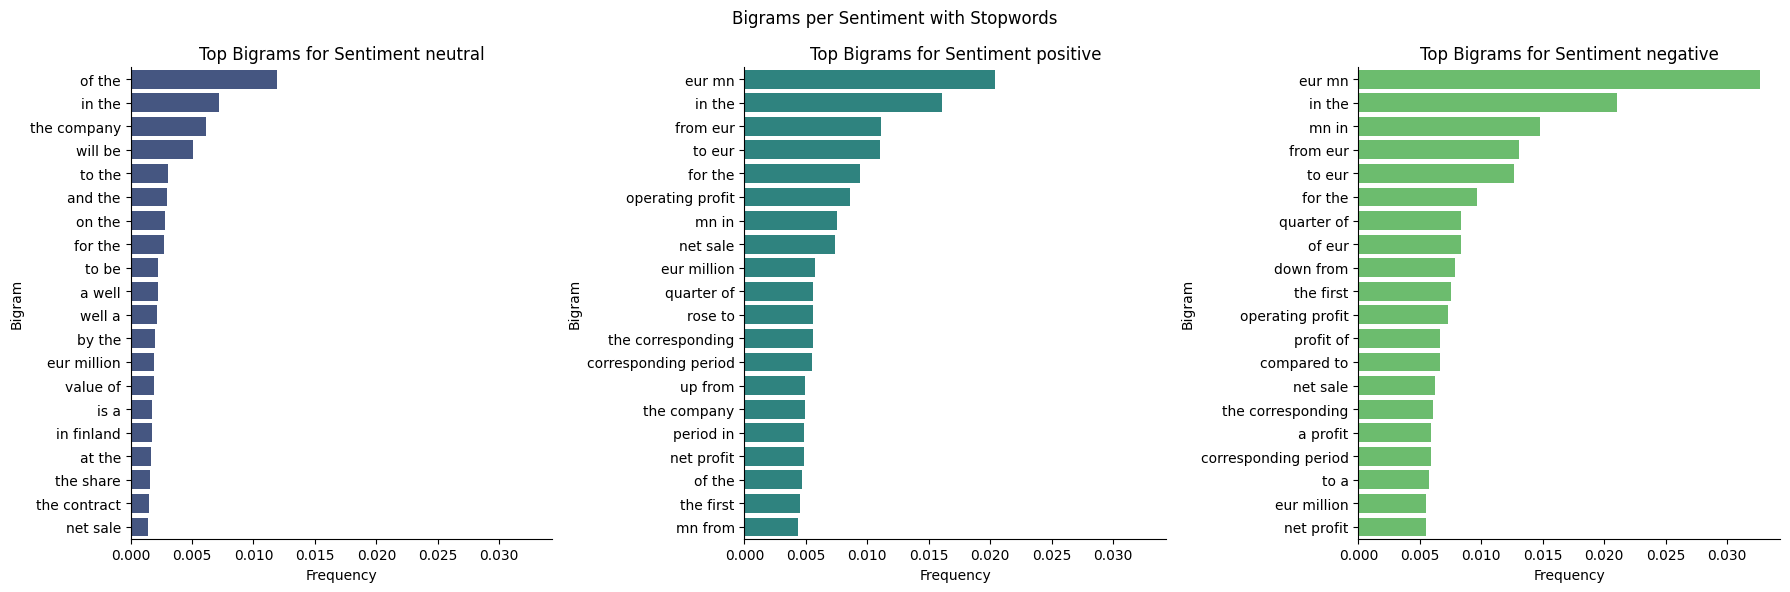

In [38]:
fig, axes = plt.subplots(1, num_labels, figsize=(6*num_labels, 6), sharex=True)

for ax, label in zip(axes, labels):
    top_words = top_ngrams_for_label(df, label, [], 2, 20, lemmatizer)
    sns.barplot(x=top_words.values, y=top_words.index, ax=ax, color=sentiment_colors[label])
    ax.set_title(f"Top Bigrams for Sentiment {label}")
    ax.set_xlabel("Frequency")
    ax.set_ylabel("Bigram")

sns.despine()
plt.suptitle('Bigrams per Sentiment with Stopwords')
plt.tight_layout()
plt.show()

Analyzing bigrams with stopwords provides a clearer view of common phrase structures and the typical reporting patterns used in each sentiment class. Unlike unigrams, bigrams reveal how words combine into meaningful financial expressions, making sentiment‑specific patterns more explicit.

The neutral bigrams are dominated by structural and descriptive phrases such as of the, in the, the company, to the, and for the. These combinations reflect the informational and administrative tone typical of neutral reporting. The presence of will be and to be suggests that neutral texts often describe plans, procedures, or future events without attaching sentiment.
Overall, the neutral bigrams reinforce that this class is characterized by non‑evaluative corporate and contextual descriptions, rather than performance outcomes. n the positive class, bigrams reveal performance‑oriented financial expressions that were less visible in the unigram analysis. Several bigrams directly encode upward movement or improved results like 'operating profit', 'net sale', 'net profit', 'rose to' and 'up from'. These phrases clearly indicate growth, improvement, or favorable comparisons, which are central to positive sentiment.
Additionally, monetary expressions such as eur mn, from eur, to eur, and eur million appear frequently, reflecting the tendency of positive news to quantify gains.
Bigrams like the corresponding and corresponding period show that positive sentences often rely on year‑over‑year or quarter‑over‑quarter comparisons to highlight improvements.

The negative bigrams share some structural patterns with the positive class, but the key differences become much clearer at the bigram level. The bigram 'down from' explicitly signal decline or deterioration. As in the positive class, financial reporting terms such as operating profit, net sale, net profit, and eur million appear frequently.

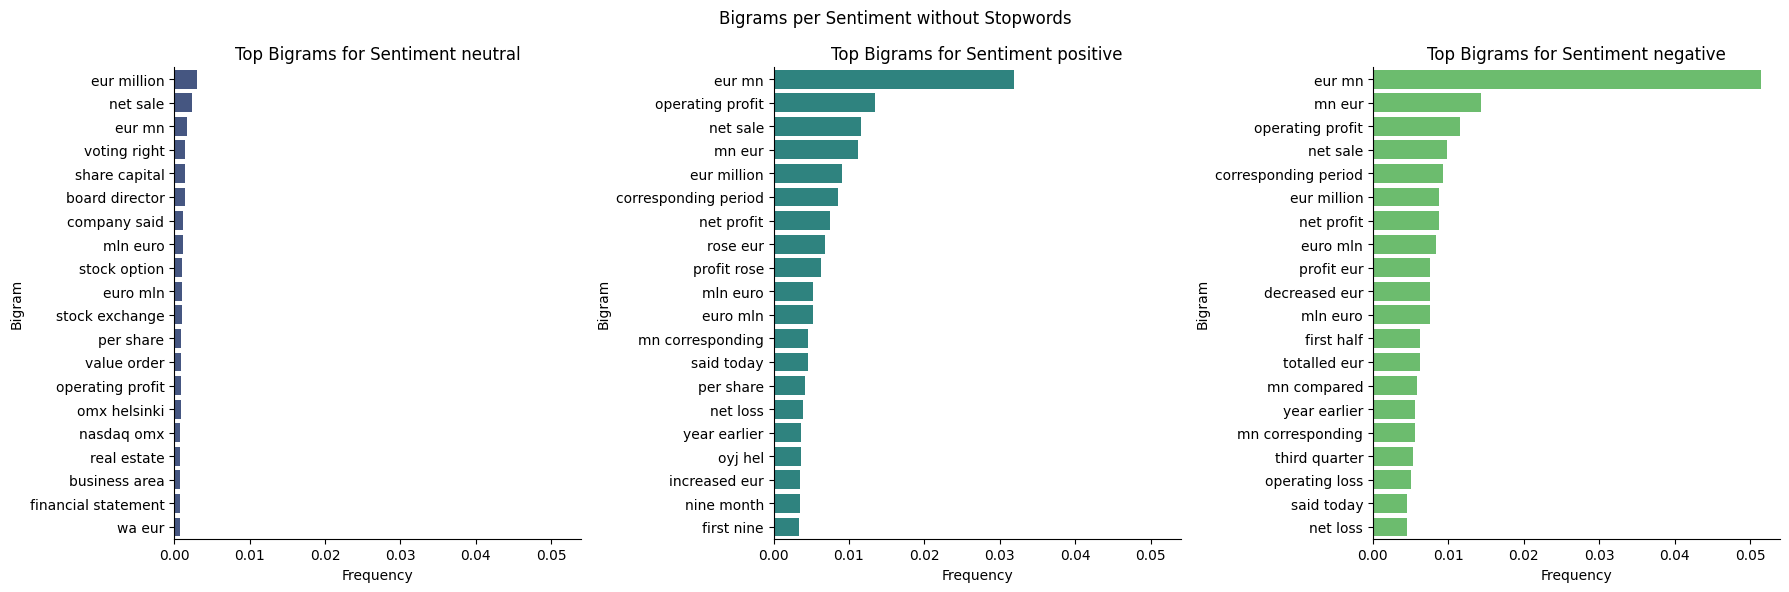

In [39]:
fig, axes = plt.subplots(1, num_labels, figsize=(6*num_labels, 6), sharex=True)

for ax, label in zip(axes, labels):
    top_words = top_ngrams_for_label(df, label, stop_words, 2, 20, lemmatizer)
    sns.barplot(x=top_words.values, y=top_words.index, ax=ax, color=sentiment_colors[label])
    ax.set_title(f"Top Bigrams for Sentiment {label}")
    ax.set_xlabel("Frequency")
    ax.set_ylabel("Bigram")

sns.despine()
plt.suptitle('Bigrams per Sentiment without Stopwords')
plt.tight_layout()
plt.show()

Removing stopwords from the bigram analysis exposes the core semantic building blocks of financial reporting. Unlike the stopword‑inclusive bigrams, which were dominated by generic phrase templates, the stopword‑free bigrams reveal meaningful multi‑word expressions that directly encode financial concepts, corporate actions, and sentiment‑relevant developments.

The neutral bigrams now clearly reflect administrative, structural, and institutional language. Phrases such as 'voting right', 'share capital', 'stock option', 'stok exchange' and 'financial statement', indicate that neutral sentences frequently describe governance, ownership structures, regulatory contexts, and corporate formalities. The presence of eur million, eur mn, and mln euro shows that financial quantities appear, but they are not embedded in directional or evaluative contexts.

In the positive class, the stopword‑free bigrams reveal explicit performance‑oriented expressions that were only partially visible before. Key examples include 'operating profit', 'net sale', 'net profit', 'profit rose', 'rose eur' and 'increased eur'. Bigrams like corresponding period, year earlier, nine month, and first nine show that positive reporting frequently relies on comparative time‑based framing to highlight growth.

The negative bigrams reveal a pattern that is structurally similar to the positive class but semantically opposite. Key downward‑oriented expressions include 'decreased eur, 'operating loss' and 'net loss'. he bigram first half and third quarter indicate that negative reporting often focuses on specific periods of underperformance.



# TF-IDF Analysis 

This chapter examines the textual characteristics of the dataset using Term Frequency–Inverse Document Frequency (TF‑IDF), a widely used method for quantifying the importance of words within a corpus. While earlier sections focused on raw frequency counts of unigrams and bigrams, TF‑IDF provides a more refined perspective by down‑weighting extremely common terms and highlighting expressions that are particularly distinctive for each sentiment class. This allows identifying vocabulary that is more representative of the underlying semantic differences between neutral, positive, and negative financial statements.

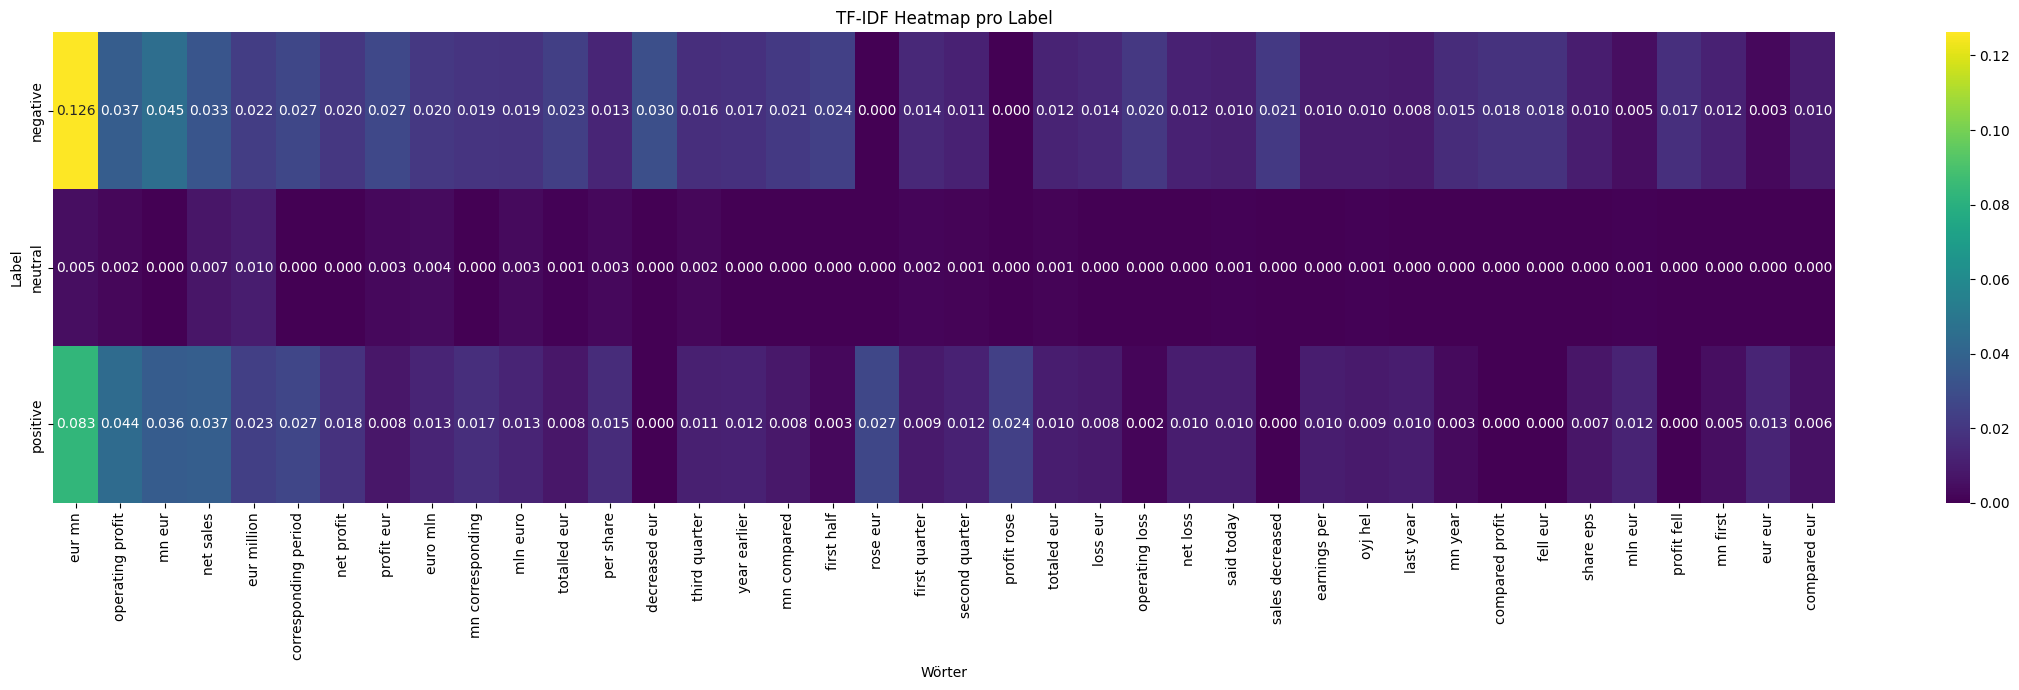

In [40]:
vectorizer = TfidfVectorizer(
    max_features=3000,
    stop_words=stop_words,
    ngram_range=(2, 2)
)

df["clean_text"] = df["text"].apply(clean_text_for_tfidf)
tfidf = vectorizer.fit_transform(df["clean_text"])
df_tfidf = pd.DataFrame(tfidf.toarray(), columns=vectorizer.get_feature_names_out())
df_tfidf["label"] = df["label"]

tfidf_means = df_tfidf.groupby("label").mean()

top_features = tfidf_means.mean().sort_values(ascending=False).head(40).index

tfidf_top = tfidf_means[top_features]

plt.figure(figsize=(23, 7))
sns.heatmap(tfidf_top, cmap="viridis", annot=True, fmt=".3f")
plt.title("TF-IDF Heatmap pro Label")
plt.xlabel("Wörter")
plt.ylabel("Label")
plt.tight_layout()
plt.show()

The TF‑IDF heatmap provides a comparative view of how strongly specific terms and bigrams are associated with each sentiment class. Because the values represent the average TF‑IDF score per label, higher values indicate that a term is more characteristic for that sentiment category, while lower values suggest that the term appears rarely or without particular relevance.

Across the heatmap, the negative class consistently exhibits the highest TF‑IDF scores for most of the selected features. Terms such as 'eur mn', 'profit fell', 'fell eur', and 'compared profit' show strong weights in negative sentences. This pattern reflects the linguistic structure of negative financial news, which frequently emphasizes declining performance, losses, or deteriorating financial indicators. The prominence of numerical expressions also suggests that negative statements tend to include detailed quantitative information, often in the context of reporting decreases or unfavorable comparisons.

The positive class shows medium‑level TF‑IDF scores for many of the same financial terms, but with a different emphasis. Positive sentences frequently contain expressions related to operational performance and year‑over‑year comparisons, such as 'operating profit', 'net sales', and 'last year'. While numerical terms are also common in positive statements, their TF‑IDF values are generally lower than in the negative class.

In contrast, the neutral class displays uniformly low TF‑IDF values across nearly all features. This indicates that neutral sentences rarely contain the performance‑related vocabulary that characterizes positive and negative financial reporting. Instead, neutral statements tend to focus on descriptive, structural, or factual information without referencing financial outcomes, trends, or comparisons. The near‑zero TF‑IDF scores for terms such as 'fell eur', 'profit fell', and 'compared profit' confirm that evaluative or directional language is largely absent from neutral content.

Overall, the heatmap highlights clear linguistic distinctions between the sentiment categories. Negative sentences are marked by dense numerical reporting and decline‑related terminology, positive sentences by performance‑oriented and comparative expressions, and neutral sentences by the absence of sentiment‑bearing financial vocabulary. These patterns demonstrate that TF‑IDF effectively captures the characteristic language of each sentiment class and provides a meaningful basis for subsequent classification tasks.

# Conclusion

This exploratory analysis provided an initial understanding of the Financial PhraseBank dataset and helped uncover the linguistic tendencies that appear across positive, negative, and neutral financial statements. While the differences between the sentiment classes were not sharply defined, the analysis revealed several recurring patterns in vocabulary usage, numerical expressions, and performance‑related terminology. The TF‑IDF inspection highlighted which terms tend to be more characteristic for each sentiment category, even though the distinctions remain subtle and context‑dependent.